In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from src.models import VAE, vae_loss
from src.data_preprocessing import load_data_from_directory, extract_and_normalize_peak_segments, plot_random_segments
from src.train import generate_synthetic_peaks
import torch.optim as optim


%load_ext autoreload
%autoreload 2

## Load and preprocess data

In [2]:
fft_data = load_data_from_directory(directory='../data/processed/Final Anomalous')
segment_length = 6
target_frequency = 150

normalized_peak_segments, minmax_stats = extract_and_normalize_peak_segments(
    fft_data, 
    segment_length=segment_length,
    target_frequency=target_frequency, 
    method='min-max'
)

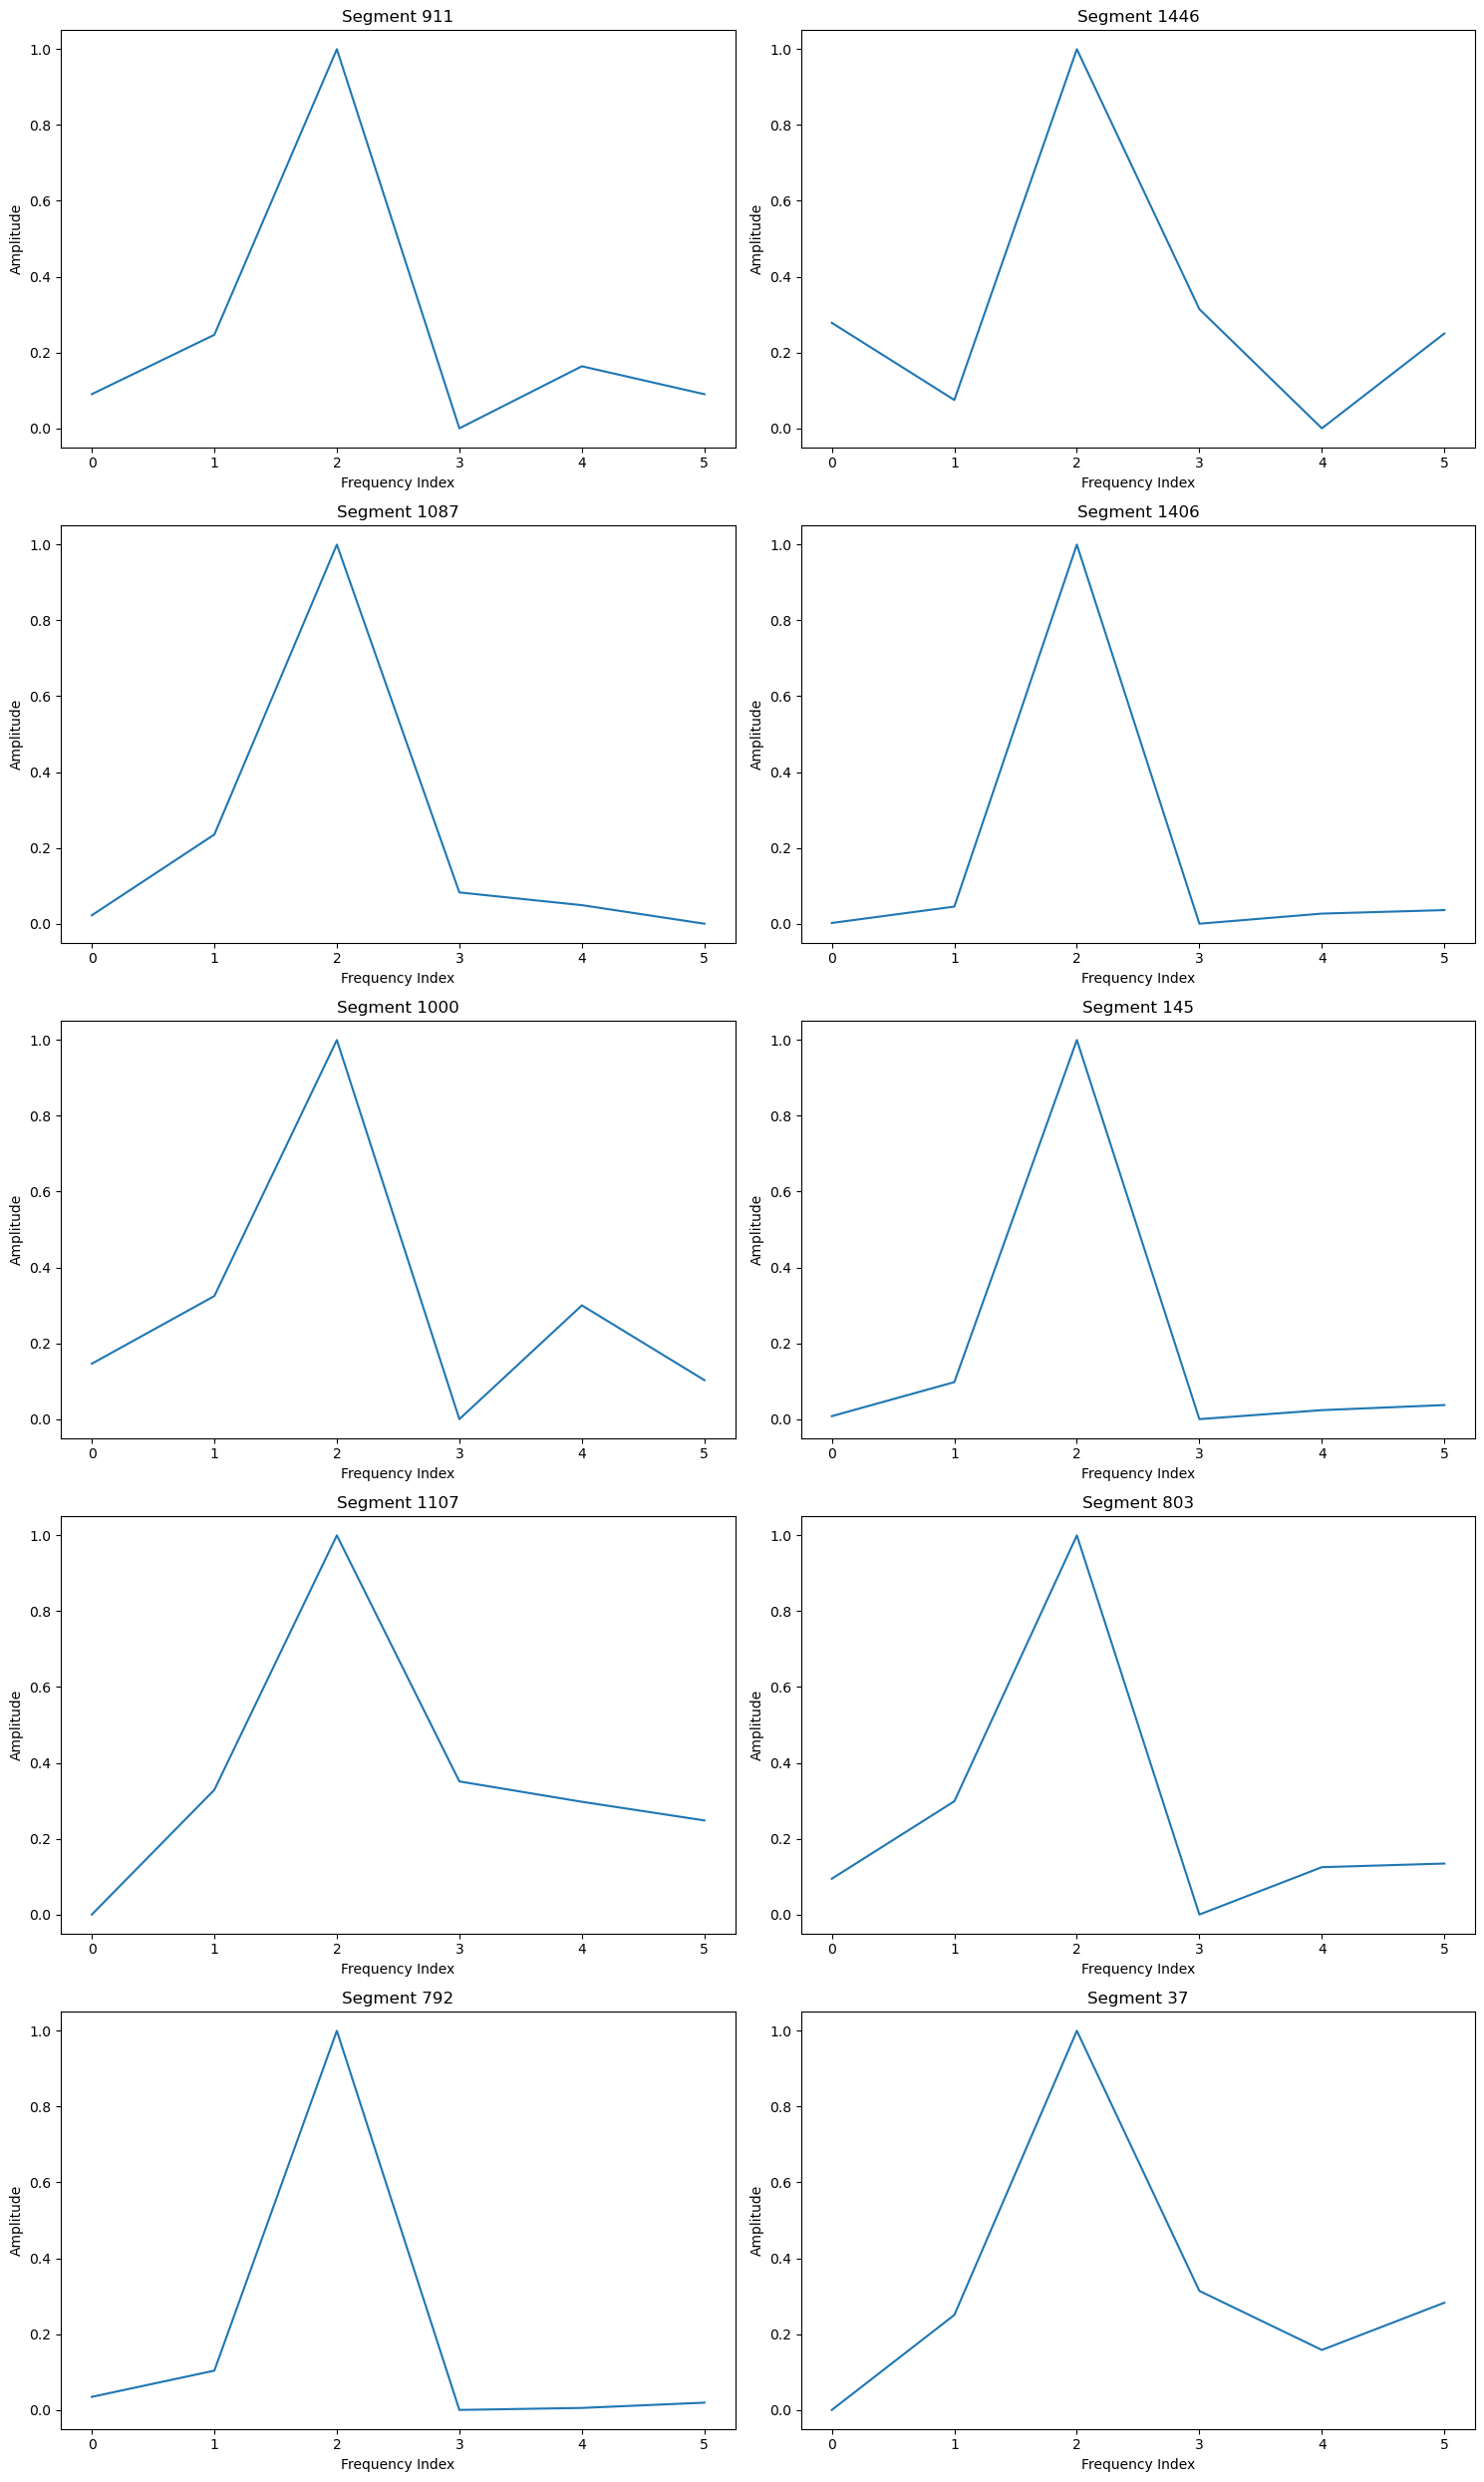

In [3]:
# Plot some segments
plot_random_segments(normalized_peak_segments)

In [4]:
# Prepare data for training
data = torch.tensor(normalized_peak_segments, dtype=torch.float32)
input_shape = data.shape[1]
latent_dim = 10
batch_size = 32
data = data.view(-1, 1, input_shape)
dataset = TensorDataset(data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
# Training parameters
epochs = 50
lr = 0.0001

# Initialize model and optimizer
vae = VAE(input_dim=input_shape, latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)

## Train the VAE

In [14]:
from src.train import train_vae

train_vae(vae, dataloader, optimizer, num_epochs=epochs)

Training:   0%|          | 0/2350 [00:00<?, ?batch/s]

Epoch 1/50, Avg Loss: 0.00225
Epoch 2/50, Avg Loss: 0.00227
Epoch 3/50, Avg Loss: 0.00226
Epoch 4/50, Avg Loss: 0.00227
Epoch 5/50, Avg Loss: 0.00227
Epoch 6/50, Avg Loss: 0.00228
Epoch 7/50, Avg Loss: 0.00227
Epoch 8/50, Avg Loss: 0.00226
Epoch 9/50, Avg Loss: 0.00226
Epoch 10/50, Avg Loss: 0.00224
Epoch 11/50, Avg Loss: 0.00227
Epoch 12/50, Avg Loss: 0.00226
Epoch 13/50, Avg Loss: 0.00225
Epoch 14/50, Avg Loss: 0.00225
Epoch 15/50, Avg Loss: 0.00226
Epoch 16/50, Avg Loss: 0.00225
Epoch 17/50, Avg Loss: 0.00226
Epoch 18/50, Avg Loss: 0.00227
Epoch 19/50, Avg Loss: 0.00225
Epoch 20/50, Avg Loss: 0.00226
Epoch 21/50, Avg Loss: 0.00226
Epoch 22/50, Avg Loss: 0.00226
Epoch 23/50, Avg Loss: 0.00226
Epoch 24/50, Avg Loss: 0.00225
Epoch 25/50, Avg Loss: 0.00226
Epoch 26/50, Avg Loss: 0.00227
Epoch 27/50, Avg Loss: 0.00225
Epoch 28/50, Avg Loss: 0.00227
Epoch 29/50, Avg Loss: 0.00225
Epoch 30/50, Avg Loss: 0.00225
Epoch 31/50, Avg Loss: 0.00225
Epoch 32/50, Avg Loss: 0.00225
Epoch 33/50, Avg 

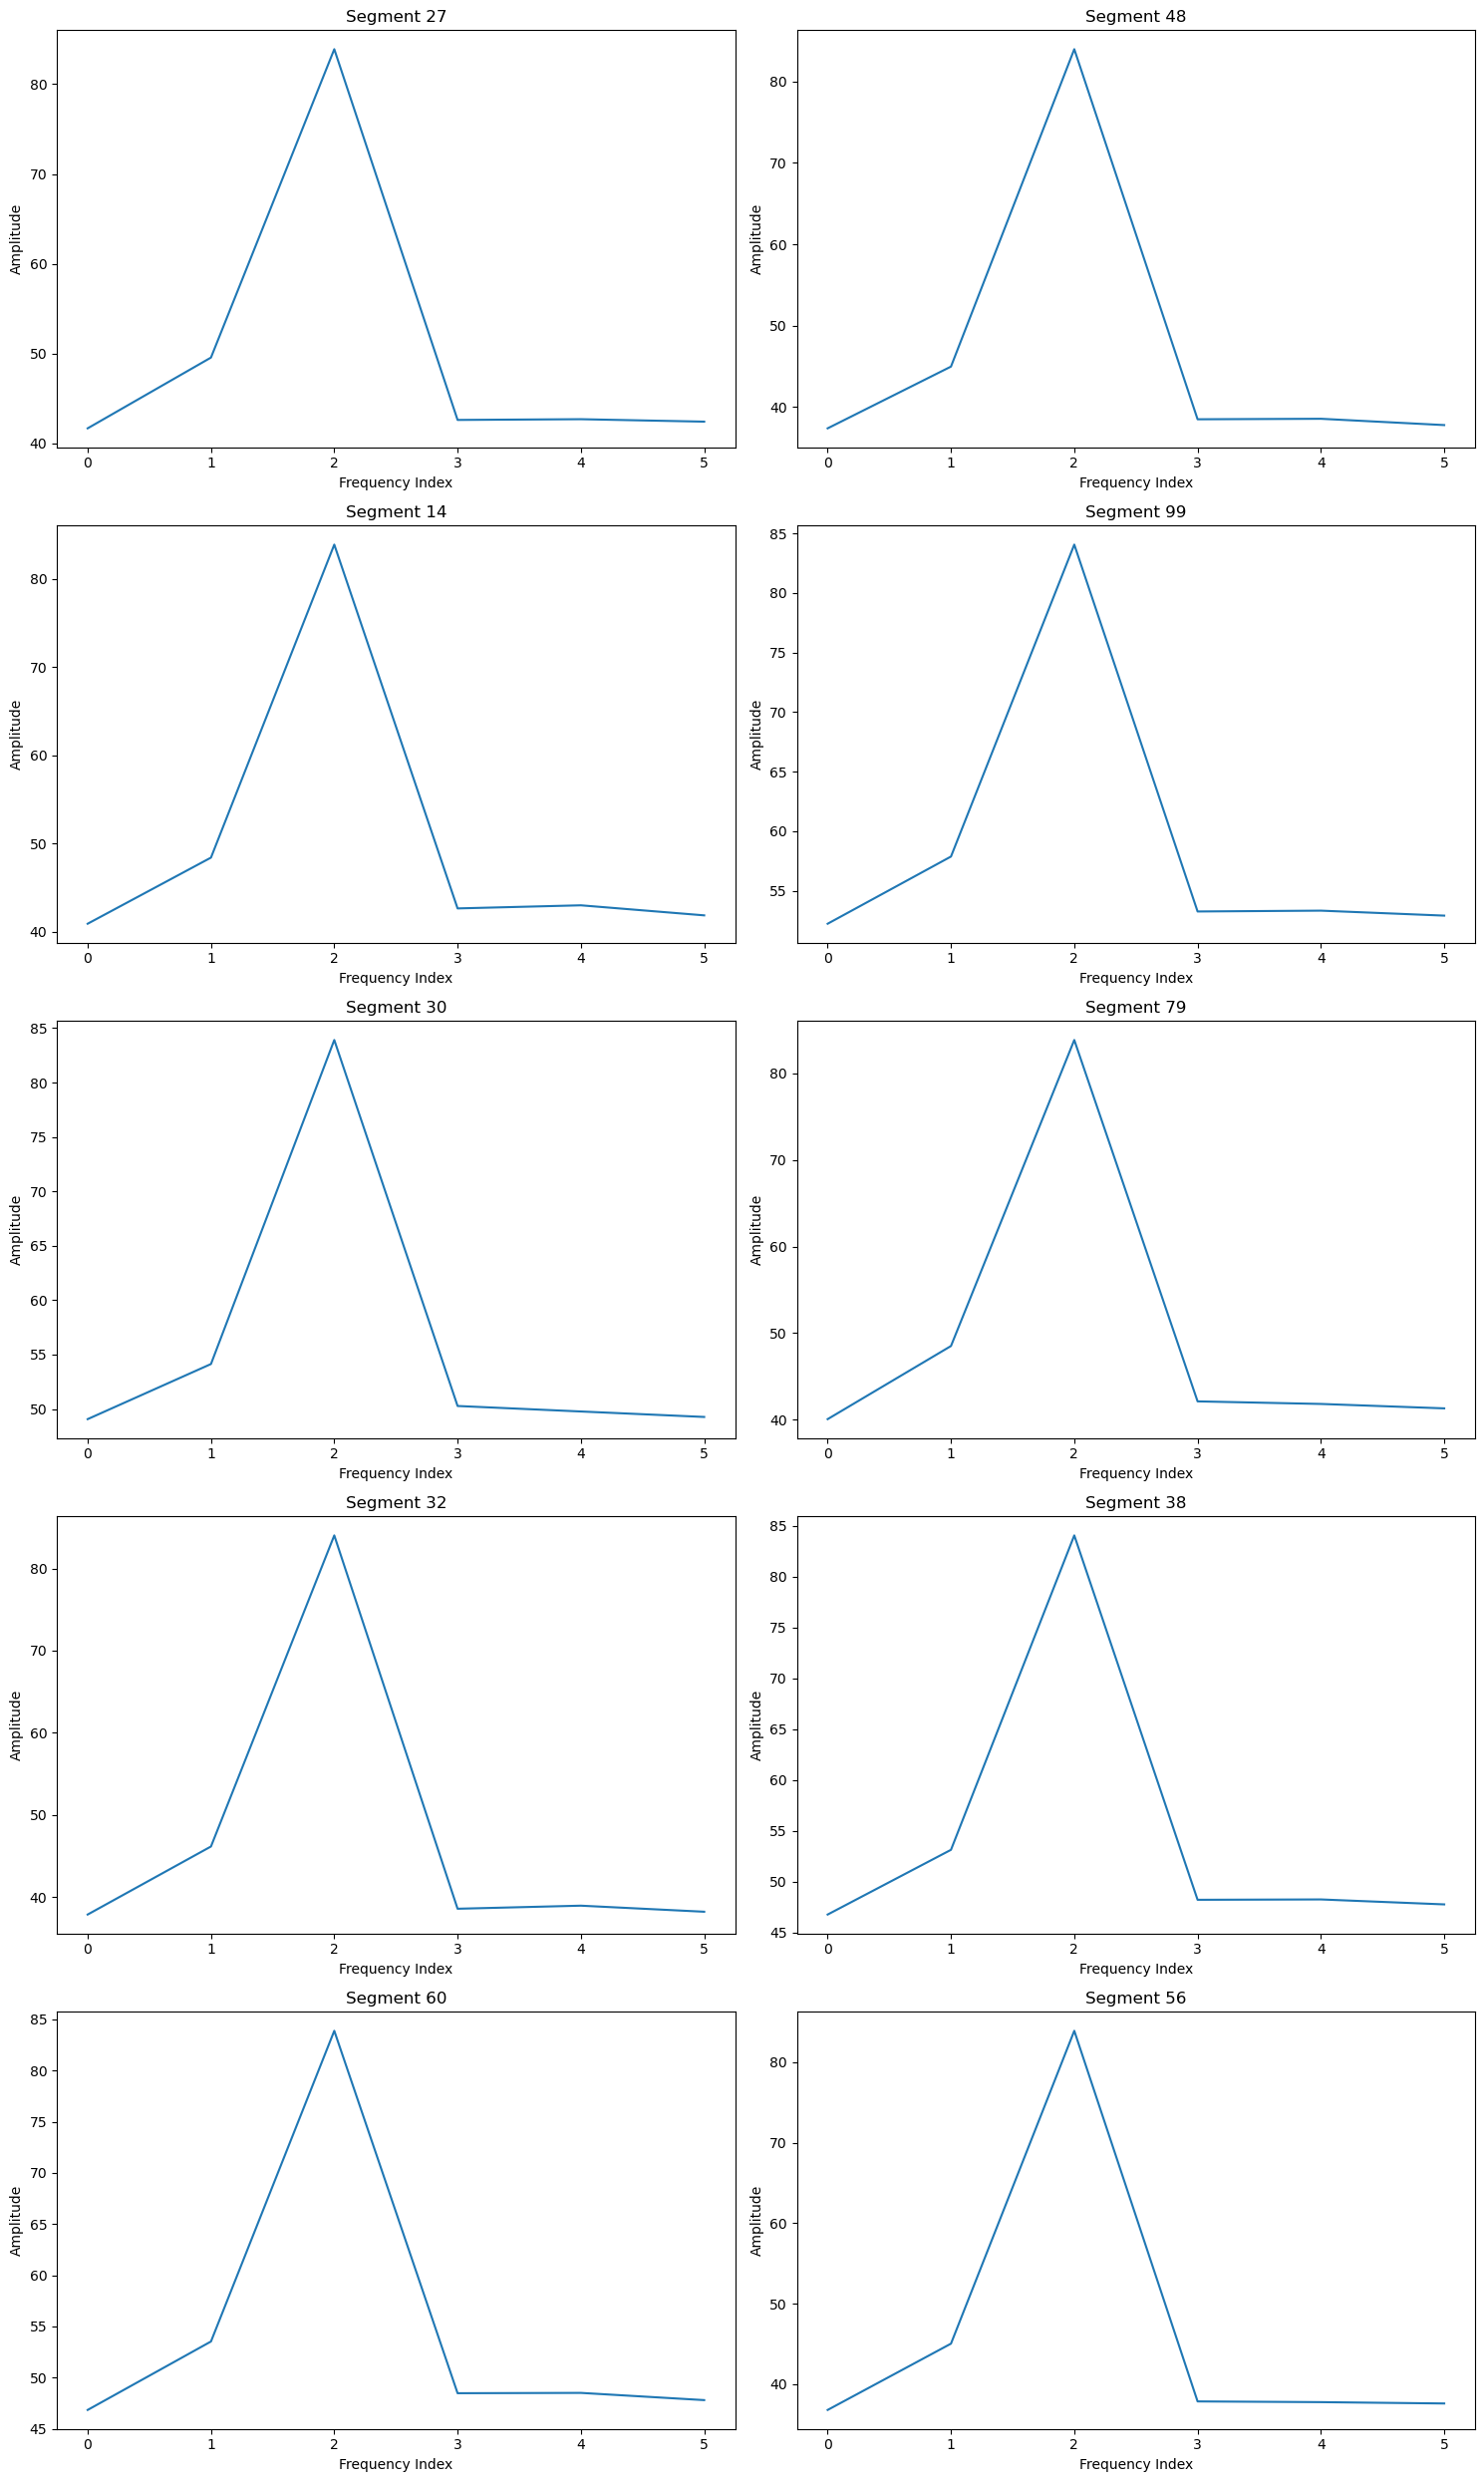

In [19]:
denormalized_peaks = generate_synthetic_peaks(vae, 100, latent_dim, segment_mins=minmax_stats[:, 0], segment_maxs=minmax_stats[:, 1])
plot_random_segments(denormalized_generated_peaks)